In [7]:
import pyspedas
import pytplot
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.cm as cm

import scipy
from scipy import interpolate,optimize
from scipy.optimize import curve_fit
from skimage.transform import probabilistic_hough_line

In [8]:
start = '2023-01-03'
end = '2023-01-04'
time_clip = True
no_update = False
varnames_hfr = 'psp_fld_l3_rfs_hfr_auto_averages_ch0_V1V2'
varnames_lfr = 'psp_fld_l3_rfs_lfr_auto_averages_ch0_V1V2'
rfs_hfr_vars = pyspedas.psp.fields(trange=[start, end], datatype='rfs_hfr', level='l3', no_update=no_update, varnames=varnames_hfr)
rfs_lfr_vars = pyspedas.psp.fields(trange=[start, end], datatype='rfs_lfr', level='l3', no_update=no_update, varnames=varnames_lfr)
rfs_ch0_hfr = pyspedas.get('psp_fld_l3_rfs_hfr_auto_averages_ch0_V1V2')
rfs_ch0_lfr = pyspedas.get('psp_fld_l3_rfs_lfr_auto_averages_ch0_V1V2')
data_hfr = rfs_ch0_hfr.y
freq_hfr = rfs_ch0_hfr.v
times_hfr = rfs_ch0_hfr.times

data_lfr = rfs_ch0_lfr.y
freq_lfr = rfs_ch0_lfr.v
times_lfr = rfs_ch0_lfr.times

10-Sep-25 17:01:20: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
10-Sep-25 17:01:20: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230103_v03.cdf
10-Sep-25 17:01:20: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
10-Sep-25 17:01:21: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230103_v03.cdf
10-Sep-25 17:01:21: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
10-Sep-25 17:01:21: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230103_v03.cdf
10-Sep-25 17:01:21: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
10-Sep-25 17:01:22: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230103_v03.cdf


In [11]:
dyspec = data_hfr
f_fits = freq_hfr[0]
t_fits = times_hfr

In [6]:
times_hfr.shape

(12359,)

In [7]:
times_hfr

array(['2023-01-03T00:00:04.368307840', '2023-01-03T00:00:11.358787072',
       '2023-01-03T00:00:18.349266176', ...,
       '2023-01-03T23:59:39.176348032', '2023-01-03T23:59:46.166827264',
       '2023-01-03T23:59:53.157306368'], dtype='datetime64[ns]')

In [8]:
times_lfr

array(['2023-01-03T00:00:06.607321728', '2023-01-03T00:00:13.597800832',
       '2023-01-03T00:00:20.588280064', ...,
       '2023-01-03T23:59:41.415606016', '2023-01-03T23:59:48.406085120',
       '2023-01-03T23:59:55.396564352'], dtype='datetime64[ns]')

In [9]:
times_lfr.shape

(12359,)

In [10]:
times_hfr - times_lfr

array([-2239013888, -2239013760, -2239013888, ..., -2239257984,
       -2239257856, -2239257984], dtype='timedelta64[ns]')

In [11]:
freq_lfr[0].shape

(64,)

In [12]:
freq_lfr[0].shape

(64,)

In [13]:
freq_hfr[0]

array([ 1275000.,  1321875.,  1378125.,  1425000.,  1471875.,  1575000.,
        1621875.,  1678125.,  1771875.,  1828125.,  1921875.,  2025000.,
        2128125.,  2221875.,  2278125.,  2371875.,  2521875.,  2625000.,
        2728125.,  2878125.,  2971875.,  3121875.,  3271875.,  3375000.,
        3525000.,  3721875.,  3871875.,  4021875.,  4228125.,  4425000.,
        4575000.,  4771875.,  5025000.,  5221875.,  5475000.,  5728125.,
        5971875.,  6225000.,  6478125.,  6778125.,  7078125.,  7425000.,
        7725000.,  8071875.,  8428125.,  8821875.,  9178125.,  9571875.,
       10021875., 10471875., 10921875., 11428125., 11925000., 12421875.,
       13021875., 13575000., 14175000., 14821875., 15478125., 16125000.,
       16875000., 17625000., 18375000., 19171876.], dtype=float32)

In [14]:
freq_lfr[0]

array([  10546.88,   18750.  ,   28125.  ,   37500.  ,   46875.  ,
         56250.  ,   65625.  ,   75000.  ,   84375.  ,   89062.5 ,
         94921.88,  100781.25,  106640.62,  112500.  ,  118359.38,
        125390.62,  132421.88,  140625.  ,  146484.38,  157031.25,
        166406.25,  175781.25,  186328.12,  196875.  ,  208593.75,
        220312.5 ,  233203.12,  247265.62,  261328.12,  276562.5 ,
        292968.75,  309375.  ,  328125.  ,  346875.  ,  366796.88,
        387890.62,  411328.12,  434765.62,  459375.  ,  486328.12,
        514453.12,  544921.9 ,  576562.5 ,  609375.  ,  645703.1 ,
        682031.25,  721875.  ,  764062.5 ,  808593.75,  855468.75,
        904687.5 ,  957421.9 , 1013671.9 , 1072265.6 , 1134375.  ,
       1196484.4 , 1265625.  , 1312500.  , 1368750.  , 1425000.  ,
       1481250.  , 1565625.  , 1621875.  , 1687500.  ], dtype=float32)

In [13]:
full_f_fits = np.concatenate((freq_lfr[0], freq_hfr[0]))
full_f_fits

array([1.0546880e+04, 1.8750000e+04, 2.8125000e+04, 3.7500000e+04,
       4.6875000e+04, 5.6250000e+04, 6.5625000e+04, 7.5000000e+04,
       8.4375000e+04, 8.9062500e+04, 9.4921883e+04, 1.0078125e+05,
       1.0664062e+05, 1.1250000e+05, 1.1835938e+05, 1.2539062e+05,
       1.3242188e+05, 1.4062500e+05, 1.4648438e+05, 1.5703125e+05,
       1.6640625e+05, 1.7578125e+05, 1.8632812e+05, 1.9687500e+05,
       2.0859375e+05, 2.2031250e+05, 2.3320312e+05, 2.4726562e+05,
       2.6132812e+05, 2.7656250e+05, 2.9296875e+05, 3.0937500e+05,
       3.2812500e+05, 3.4687500e+05, 3.6679688e+05, 3.8789062e+05,
       4.1132812e+05, 4.3476562e+05, 4.5937500e+05, 4.8632812e+05,
       5.1445312e+05, 5.4492188e+05, 5.7656250e+05, 6.0937500e+05,
       6.4570312e+05, 6.8203125e+05, 7.2187500e+05, 7.6406250e+05,
       8.0859375e+05, 8.5546875e+05, 9.0468750e+05, 9.5742188e+05,
       1.0136719e+06, 1.0722656e+06, 1.1343750e+06, 1.1964844e+06,
       1.2656250e+06, 1.3125000e+06, 1.3687500e+06, 1.4250000e

In [16]:
data_hfr.shape
# 12359 subarrays, 64 elements in each subarray

(12359, 64)

In [17]:
data_lfr.shape

(12359, 64)

In [18]:
data_lfr

array([[2.7739540e-14, 8.7548478e-15, 5.4570619e-15, ..., 3.0042326e-17,
        3.4450845e-17, 3.8895660e-17],
       [2.8640989e-14, 8.0180317e-15, 4.8044319e-15, ..., 3.5996257e-17,
        3.3647292e-17, 3.3669080e-17],
       [3.0774415e-14, 1.0118743e-14, 5.3632199e-15, ..., 2.7159374e-17,
        3.4485782e-17, 3.6102831e-17],
       ...,
       [2.5121322e-14, 9.1533362e-15, 4.6844272e-15, ..., 2.9441651e-17,
        3.0288068e-17, 2.6721648e-17],
       [2.9538475e-14, 8.4949222e-15, 4.6972326e-15, ..., 2.5430710e-17,
        2.6829426e-17, 2.3809254e-17],
       [2.7495249e-14, 9.5296196e-15, 5.0598127e-15, ..., 2.6276922e-17,
        2.8820964e-17, 2.3709635e-17]], dtype=float32)

In [15]:
full_data = np.concatenate((data_lfr, data_hfr), axis = 1)
full_data.shape

(12359, 128)

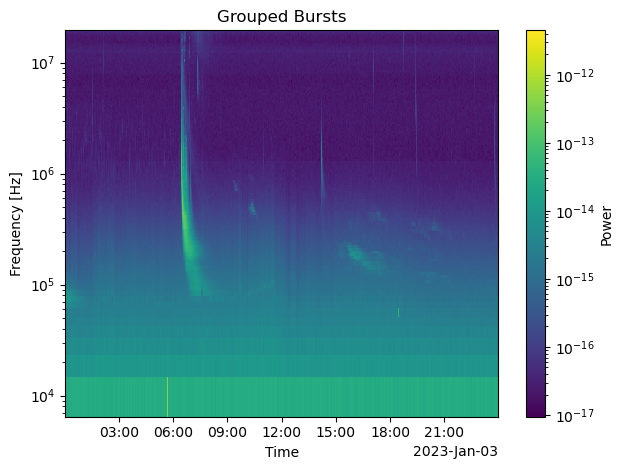

In [17]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
def binarization(data_fits_new,N_order=2,peak_r=0.30):
    # with high order local-max method 
    # original default arguments : N_order = 5
    # peak_r = 0.95
    bmap = np.ones_like(data_fits_new)
    N_pad = N_order
    local_max_arr = np.pad(data_fits_new,((N_pad,N_pad),(0,0)))
    for idx in range(N_pad-1):
        bmap=bmap* ((peak_r*local_max_arr[N_pad+idx+1:-N_pad+idx+1,:]<
                            local_max_arr[N_pad+idx:-N_pad+idx,:]) & 
                    (peak_r*local_max_arr[N_pad-idx-1:-N_pad-idx-1,:]<
                            local_max_arr[N_pad-idx:-N_pad-idx,:]) )
    return bmap

bmap = binarization(full_data)
bmap

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)

In [21]:
bmap.shape

(12359, 128)

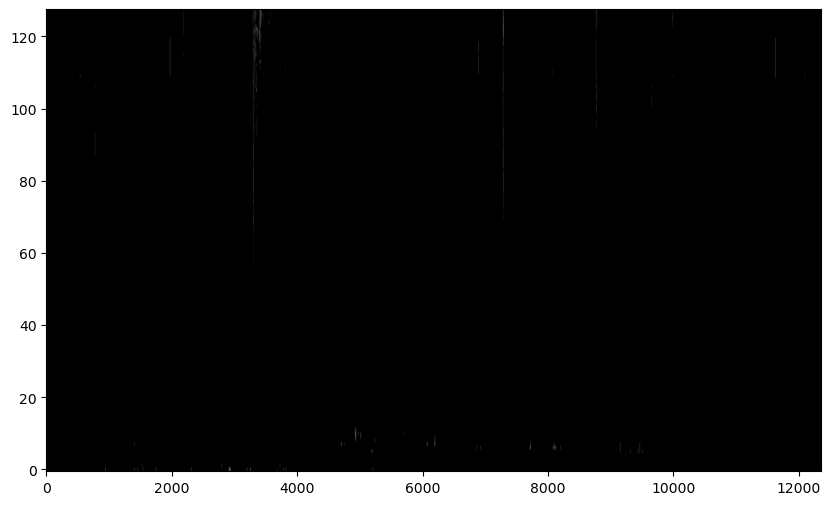

In [23]:
plt.figure(figsize=(10, 6))
plt.imshow(1-binarization(full_data, peak_r=0.3).T, aspect='auto', origin='lower',cmap='gray')
plt.show()

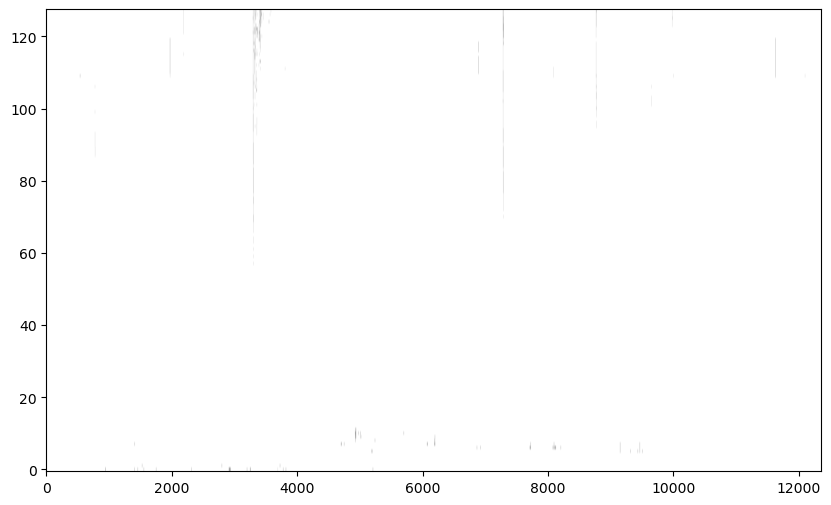

In [109]:
plt.figure(figsize=(10, 6))
plt.imshow(binarization(full_data, peak_r=0.3).T, aspect='auto', origin='lower',cmap='gray')
plt.show()

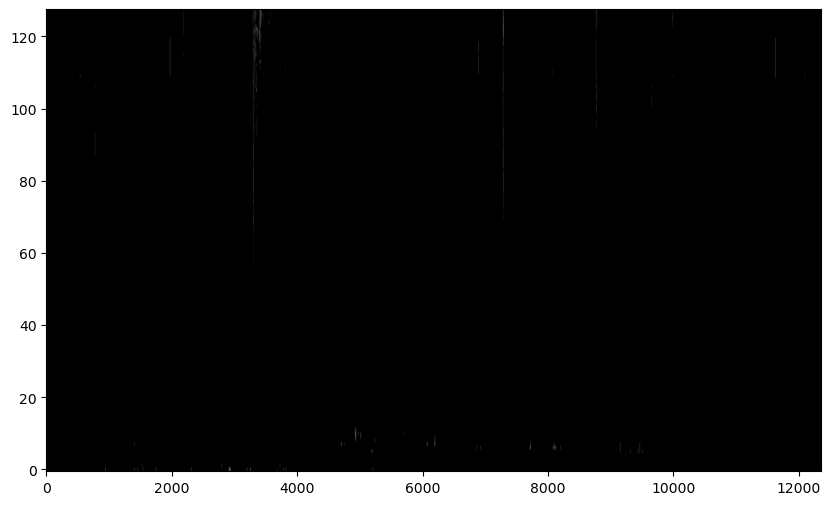

In [101]:
plt.figure(figsize=(10, 6))
plt.imshow(1-bmap.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

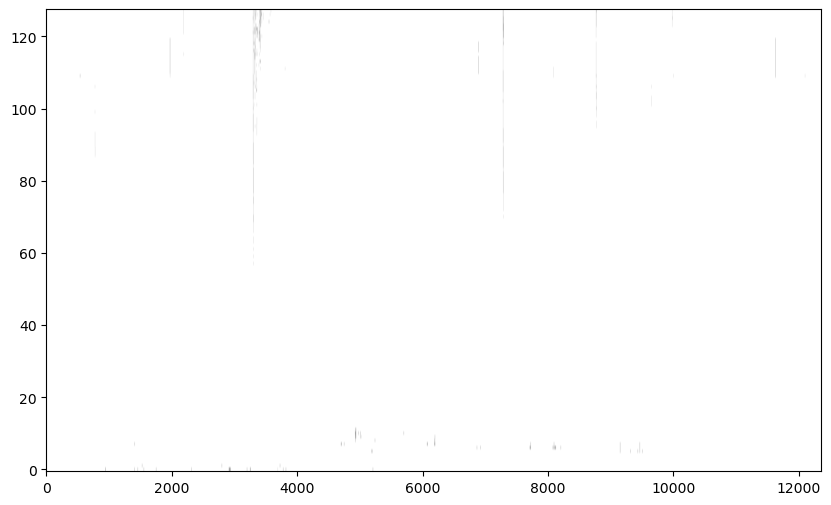

In [111]:
plt.figure(figsize=(10, 6))
plt.imshow(bmap.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

In [115]:
def hough_detect(bmap,dyspec,threshold=50,line_gap=10,line_length=25,
            theta=np.linspace(np.pi/2-np.pi/8,np.pi/2-1/180*np.pi,300)):
    threshold = 10
    line_gap = 50
    line_length = 10
    lines = probabilistic_hough_line(bmap, threshold=threshold,line_gap=line_gap,line_length=line_length,
                                 theta=theta)
    return lines

lines = hough_detect(1-bmap, dyspec)
lines

[((64, 3309), (125, 3302)),
 ((61, 3308), (121, 3302)),
 ((57, 3309), (124, 3303)),
 ((77, 7292), (127, 7289)),
 ((73, 7294), (126, 7288)),
 ((84, 7291), (110, 7289)),
 ((86, 3305), (105, 3303)),
 ((95, 3334), (127, 3332)),
 ((86, 7292), (99, 7290)),
 ((103, 8775), (125, 8772)),
 ((96, 8777), (106, 8775)),
 ((70, 7295), (127, 7288)),
 ((107, 3317), (127, 3316)),
 ((109, 8773), (126, 8772)),
 ((114, 3336), (126, 3335)),
 ((109, 11635), (119, 11635)),
 ((109, 11633), (119, 11633)),
 ((101, 3317), (126, 3315))]

In [28]:
norm = np.linalg.norm
def point_to_line_distance(p1,p2,p3):
    d = np.abs(norm(np.cross(p2-p1, p1-p3)))/norm(p2-p1)
    return d

def point_to_point_distance(p1,p2):
    return norm(p1-p2)

In [29]:
def line_grouping(lines,min_dist=3, threshmode=2): # pix
    """
    Parameters
    ----------
    lines : list
        list of lines detected by hough transform.
    min_dist : float, optional  # pix
        minimum distance between two lines to be grouped together.
    threshmode : int, optional
        DESCRIPTION. 1: only distance of point to line
                        2: distance of point to line and angle between lines
    """
    # group the detected lines into group in regard of events
    lines = sorted(lines, key=lambda i: (i[0][1]+i[1][1])/2)
    line_sets = [[lines[0]]]
    for idx,line in enumerate(lines[0:-1]):
        (A,B),(C,D) = np.array([lines[idx], lines[idx+1] ])

        # use the longer line as the reference
        l_AB = norm(A-B)
        l_CD = norm(C-D)
        if l_AB<l_CD:
            A,B,C,D = C,D,A,B
        
        # point to line distance
        Line_dist_thresh = np.min([point_to_line_distance(A,B,C),point_to_line_distance(A,B,D)])< min_dist
        Line_dist_thresh2 = np.min([point_to_line_distance(A,B,C),point_to_line_distance(A,B,D)])< min_dist*1.5

        # two lines segment not too far away
        Point_dist_thresh = np.min([point_to_point_distance(A,C),point_to_point_distance(A,D),
                                    point_to_point_distance(B,C),point_to_point_distance(B,D)])< np.max(
                                        [point_to_point_distance(A,B),point_to_point_distance(C,D)])
       
        if threshmode==1:
            final_thresh = Line_dist_thresh
        elif threshmode==2:
            final_thresh = Line_dist_thresh & Point_dist_thresh
        elif threshmode==3:
            if B[0]>C[0] and B[1]>C[1]:
                final_thresh = Line_dist_thresh2 & Point_dist_thresh

        if final_thresh:
            # the line join
            line_sets[len(line_sets)-1].append(lines[idx+1])
        else:
            # new set
            line_sets.append([lines[idx+1]])
    
    return line_sets

line_sets = line_grouping(lines)
line_sets

[[((57, 3309), (121, 3302)),
  ((61, 3308), (106, 3303)),
  ((67, 3309), (125, 3302)),
  ((64, 3309), (107, 3304))],
 [((101, 3317), (126, 3315))],
 [((95, 3334), (127, 3332)),
  ((114, 3336), (127, 3335)),
  ((116, 3336), (126, 3336))],
 [((84, 7291), (124, 7288)),
  ((91, 7290), (106, 7289)),
  ((77, 7292), (127, 7288)),
  ((73, 7294), (89, 7292))],
 [((106, 8774), (127, 8772)),
  ((95, 8778), (122, 8772)),
  ((96, 8777), (112, 8773))],
 [((109, 11633), (119, 11633))]]

<Figure size 1000x600 with 0 Axes>

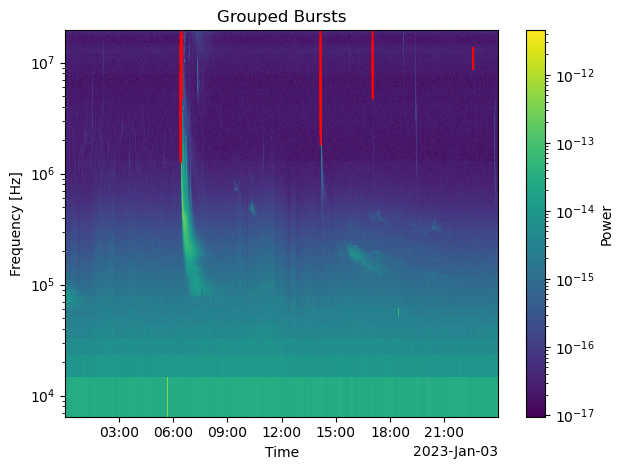

In [30]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for line_group in line_sets:
    for (x0, y0), (x1, y1) in line_group:
        t0, t1 = t_fits[y0], t_fits[y1]
        f0, f1 = full_f_fits[x0], full_f_fits[x1]
        # print(t0, t1, f0, f1)
        ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()